# SquidGame Tweet Sentiment — E2E Pipeline

In [4]:
import os, sys

# set working directory to your project root
os.chdir(r"C:\Users\yunuz\Downloads\squidgame_sentiment")
sys.path.append(os.getcwd())

# now imports will work
from src import config
from src.data_prep import load_raw, prepare
from src.eda import run_eda
from src.modeling import train_and_save, predict



In [5]:

raw = load_raw()
df = prepare(raw)
df.head()


11/11/2025 09:52:44 | INFO | data_prep | Loaded data: (80019, 12)
11/11/2025 09:52:44 | INFO | data_prep | No label column found. Creating weak labels from text/emoji rules.
11/11/2025 09:52:45 | INFO | data_prep | Prepared data: (14779, 3) | text='text' label='__weak_label'


,text,label,clean_text
1,That marble episode of #SquidGame ruined me. 😭😭😭,0,That marble episode of SquidGame ruined me. 😭😭😭
6,@B_hundred_Hyun pls use that gun on me. 😩 \n\n...,0,pls use that gun on me. 😩 BAEKHYUN EXO weareon...
7,Please vote in my daily poll. \nThanks. 😊\n\nD...,1,Please vote in my daily poll. Thanks. 😊 Do you...
12,friendship gone wrong. friendship break-ups hu...,0,friendship gone wrong. friendship break-ups hu...
13,That's definitely the first thing I saw - Who'...,1,That's definitely the first thing I saw - Who'...


In [6]:

report = run_eda(df)
report


11/11/2025 09:52:49 | INFO | eda | EDA report saved at C:\Users\yunuz\Downloads\squidgame_sentiment\eda\eda_report.json


{'n_rows': 14779,
 'n_cols': 3,
 'label_balance': {1: 11213, 0: 3566},
 'avg_len': 82.49597401718655,
 'top_words_sample': {'squidgame': 11086,
  'the': 6668,
  'i': 4995,
  'is': 3484,
  'a': 3454,
  'to': 3303,
  'and': 3282,
  'of': 2888,
  'this': 2478,
  'in': 2062,
  'it': 1928,
  'squid': 1848,
  'for': 1760,
  'you': 1718,
  'game': 1675,
  'good': 1664,
  'was': 1620,
  'so': 1562,
  'on': 1375,
  'my': 1361}}

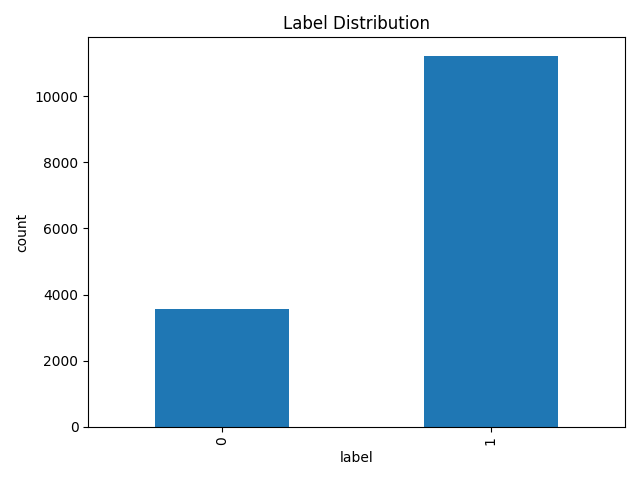

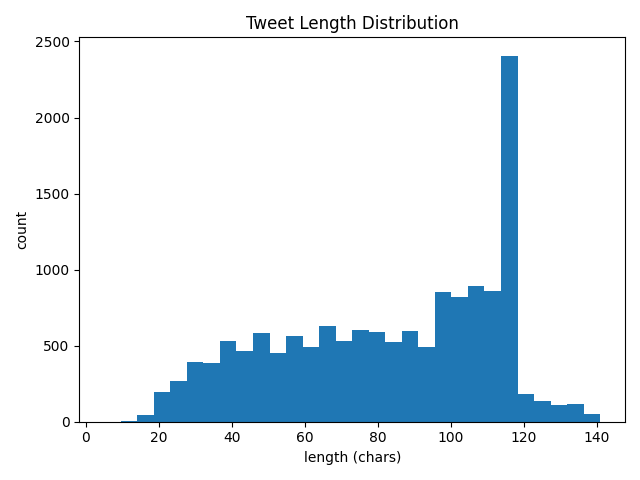

In [7]:

# Show charts
from IPython.display import Image, display
display(Image(filename=str(config.CHART_DIR / "label_distribution.png")))
display(Image(filename=str(config.CHART_DIR / "length_hist.png")))


In [8]:

metrics = train_and_save(df)
metrics["accuracy"]


11/11/2025 09:53:00 | INFO | modeling | Saved model to C:\Users\yunuz\Downloads\squidgame_sentiment\models\model.pkl | vectorizer to C:\Users\yunuz\Downloads\squidgame_sentiment\models\vectorizer.pkl | acc=0.8948


0.8947902571041949

In [ ]:

# Quick inference check
preds, probs = predict([
    "That marble episode of #SquidGame ruined me 😭😭😭",
    "SquidGame was amazing and intense, loved it!"
])
list(zip(preds, probs))


[(np.int64(0), np.float64(0.12079925319346403)),
 (np.int64(1), np.float64(0.9982437270216765))]

: 